In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_csv('dataset2.csv')

## Finding Number of models sold with and without discount

In [2]:

total_models = df['model_name'].nunique()
print("Total number of models:", total_models)

df['discount_flag'] = df['discount_applied_status'].map({
    0: 'No Discount',
    1: 'Discount'
})

model_counts = df.groupby('model_name')['discount_flag'].nunique()


valid_models = model_counts[model_counts == 2]


count_valid_models = valid_models.shape[0]

print("Number of models with both Discount and No Discount:", count_valid_models)

Total number of models: 899
Number of models with both Discount and No Discount: 895


## Units Sold for Each Model Vs Discount Status

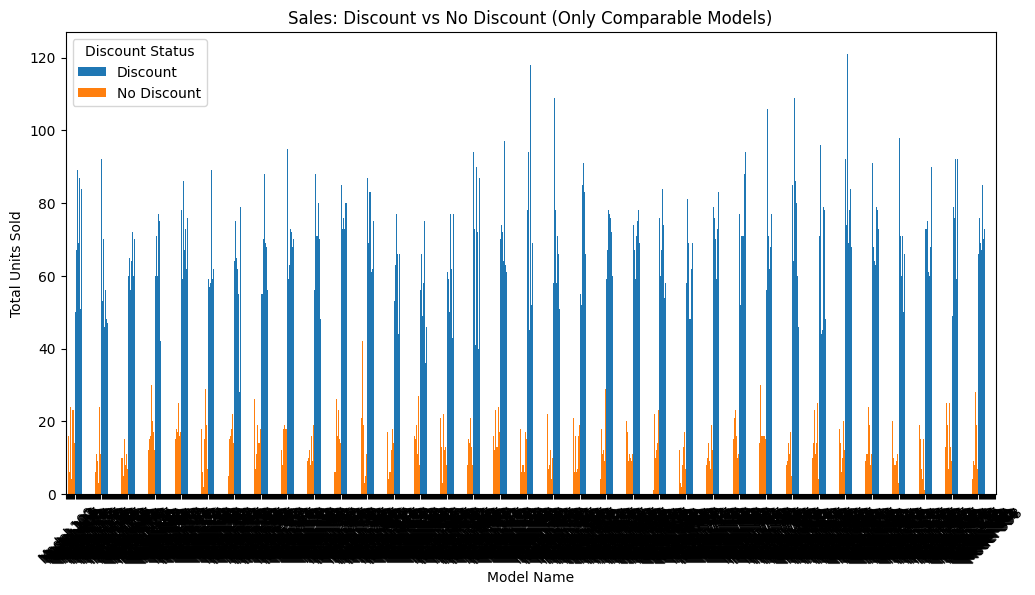

In [3]:
grouped = df.groupby(['model_name', 'discount_flag'])['units_sold'].sum().reset_index()

pivot_df = grouped.pivot(
    index='model_name',
    columns='discount_flag',
    values='units_sold'
).fillna(0)

pivot_df = pivot_df[(pivot_df['No Discount'] > 0) & (pivot_df['Discount'] > 0)]

import matplotlib.pyplot as plt

pivot_df.plot(kind='bar', figsize=(12,6))

plt.xlabel('Model Name')
plt.ylabel('Total Units Sold')
plt.title('Sales: Discount vs No Discount (Only Comparable Models)')

plt.xticks(rotation=45)
plt.legend(title='Discount Status')

plt.show()

- Selecting top 20 that has high difference for better visibility

discount_flag  Discount  No Discount
model_name                          
Model-863         120.0         20.0
Model-855         121.0         11.0
Model-508         111.0         17.0
Model-174          98.0         29.0
Model-527         105.0         22.0
Model-604         106.0         21.0
Model-549         118.0          7.0
Model-683         105.0         19.0
Model-107         101.0         23.0
Model-804         109.0         14.0
Model-342          88.0         35.0
Model-565         101.0         22.0
Model-572         109.0         13.0
Model-716         111.0         11.0
Model-261         103.0         18.0
Model-670         108.0         12.0
Model-309         108.0         12.0
Model-535          95.0         24.0
Model-214          86.0         33.0
Model-210         103.0         16.0


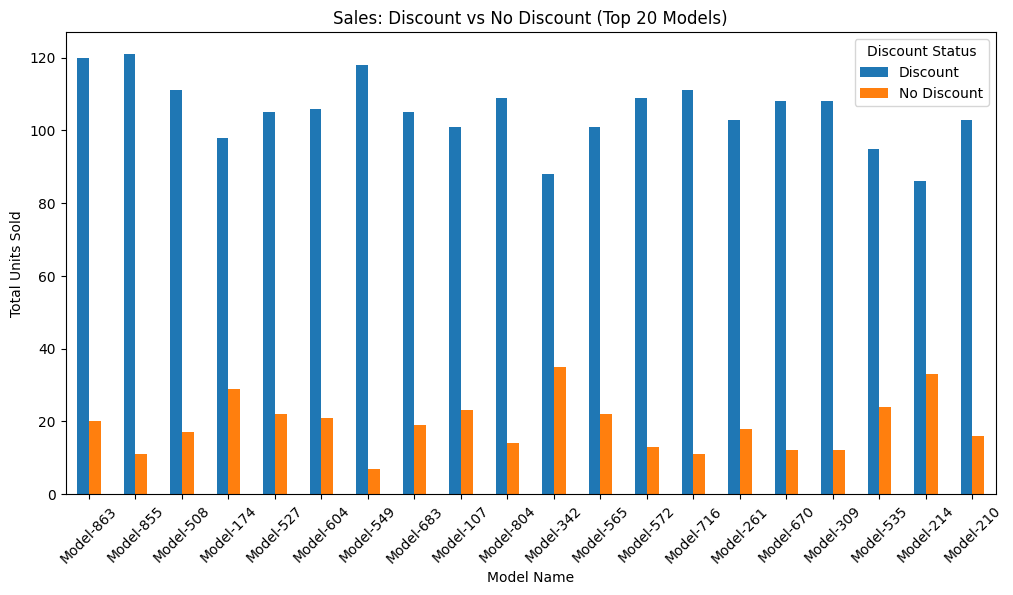

In [4]:
grouped = df.groupby(['model_name', 'discount_flag'])['units_sold'].sum().reset_index()

pivot_df = grouped.pivot(
    index='model_name',
    columns='discount_flag',
    values='units_sold'
).fillna(0)

pivot_df = pivot_df[(pivot_df['No Discount'] > 0) & (pivot_df['Discount'] > 0)]

pivot_df['total'] = pivot_df['Discount'] + pivot_df['No Discount']
pivot_df = pivot_df.sort_values(by='total', ascending=False).head(20)


print(pivot_df[['Discount', 'No Discount']])

import matplotlib.pyplot as plt

pivot_df[['Discount', 'No Discount']].plot(kind='bar', figsize=(12,6))

plt.xlabel('Model Name')
plt.ylabel('Total Units Sold')
plt.title('Sales: Discount vs No Discount (Top 20 Models)')

plt.xticks(rotation=45)
plt.legend(title='Discount Status')

plt.show()

## Number of Orders for Each Model Vs Discount Status

discount_flag  With Discount  Without Discount  difference
model_name                                                
Model-863               46.0               7.0        39.0
Model-690               41.0              10.0        31.0
Model-565               43.0               8.0        35.0
Model-604               39.0               9.0        30.0
Model-527               39.0               9.0        30.0
Model-549               45.0               3.0        42.0
Model-384               39.0               9.0        30.0
Model-134               37.0              11.0        26.0
Model-855               41.0               6.0        35.0
Model-410               41.0               6.0        35.0
Model-683               40.0               7.0        33.0
Model-309               41.0               6.0        35.0
Model-279               40.0               7.0        33.0
Model-435               44.0               3.0        41.0
Model-168               37.0               9.0        28

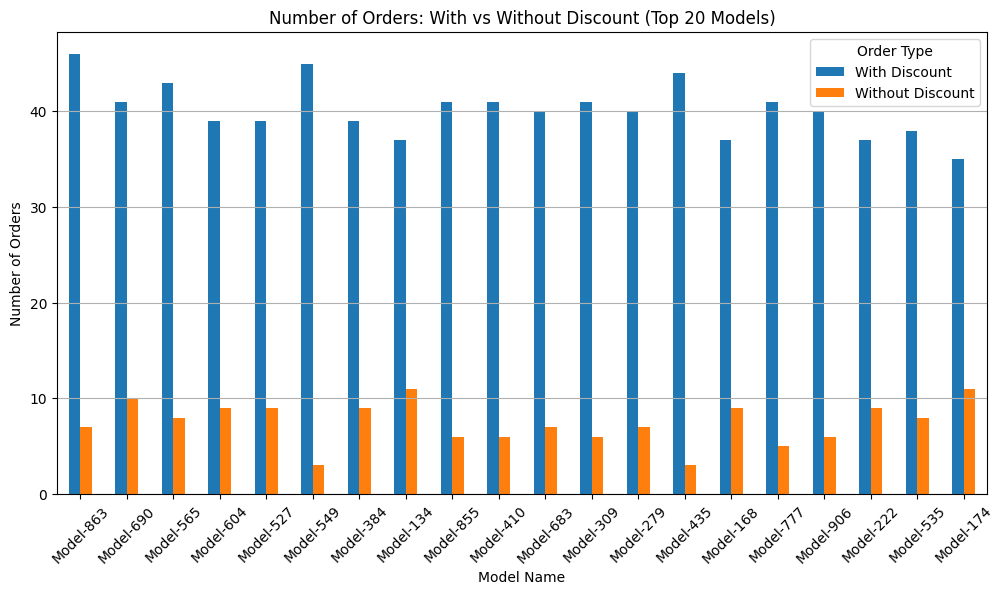

In [5]:
import matplotlib.pyplot as plt

df['discount_flag'] = df['discount_applied_status'].map({
    0: 'No Discount',
    1: 'Discount'
})

grouped = df.groupby(['model_name', 'discount_flag'])['order_id'].count().reset_index()

pivot_df = grouped.pivot(
    index='model_name',
    columns='discount_flag',
    values='order_id'
).fillna(0)

pivot_df = pivot_df[(pivot_df['No Discount'] > 0) & (pivot_df['Discount'] > 0)]

pivot_df['difference'] = pivot_df['Discount'] - pivot_df['No Discount']

pivot_df['total'] = pivot_df['Discount'] + pivot_df['No Discount']
pivot_df = pivot_df.sort_values(by='total', ascending=False).head(20)

pivot_df.rename(columns={
    'Discount': 'With Discount',
    'No Discount': 'Without Discount'
}, inplace=True)

print(pivot_df[['With Discount', 'Without Discount', 'difference']])

pivot_df[['With Discount', 'Without Discount']].plot(kind='bar', figsize=(12,6))

plt.xlabel('Model Name')
plt.ylabel('Number of Orders') 
plt.title('Number of Orders: With vs Without Discount (Top 20 Models)')

plt.xticks(rotation=45)
plt.legend(title='Order Type')

plt.grid(axis='y')
plt.show()